# 기계 예측 유지보수 분류

센서 데이터를 분석하여 기계의 이상 상태를 탐지하는 머신러닝 프로젝트입니다.

**주요 내용**:
- 지도학습 모델 (SVM, Random Forest, Gradient Boosting, XGBoost)
- 비지도학습 모델 (K-Means, GMM, Isolation Forest)
- 모델 성능 비교 및 평가
- 특성 중요도 분석

## 1단계: 라이브러리 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, roc_auc_score, 
                             roc_curve, f1_score, precision_score, recall_score, 
                             accuracy_score, silhouette_score)

# 지도학습 모델
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# 비지도학습 모델
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# 클래스 불균형 처리
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# 시각화 설정
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# 한글 폰트 설정 (Windows 환경)
plt.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

## 2단계: 데이터 로드 및 탐색

In [2]:
df = pd.read_csv('predictive_maintenance.csv')

print(f"\n데이터 크기: {df.shape}")
print(f"메모리 사용: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n처음 5개 행:\n{df.head()}")
print(f"\n기본 통계:\n{df.describe()}")


데이터 크기: (10000, 10)
메모리 사용: 2.33 MB

처음 5개 행:
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
0                    1551         42.8                0       0   No Failure  
1                    1408         46.3                3       0   No Failure  
2                    1498         49.4                5       0   No Failure  
3                    1433         39.5                7       0   No Failure  
4                    1408         40.0                9       0   No Failure  

기본 통계:
               UDI  Air temperature [K

결측치: 0

클래스 분포 (이상 탐지):
정상(0): 9,652개 (96.52%)
이상(1): 348개 (3.48%)

불균형 비율: 1:27.74


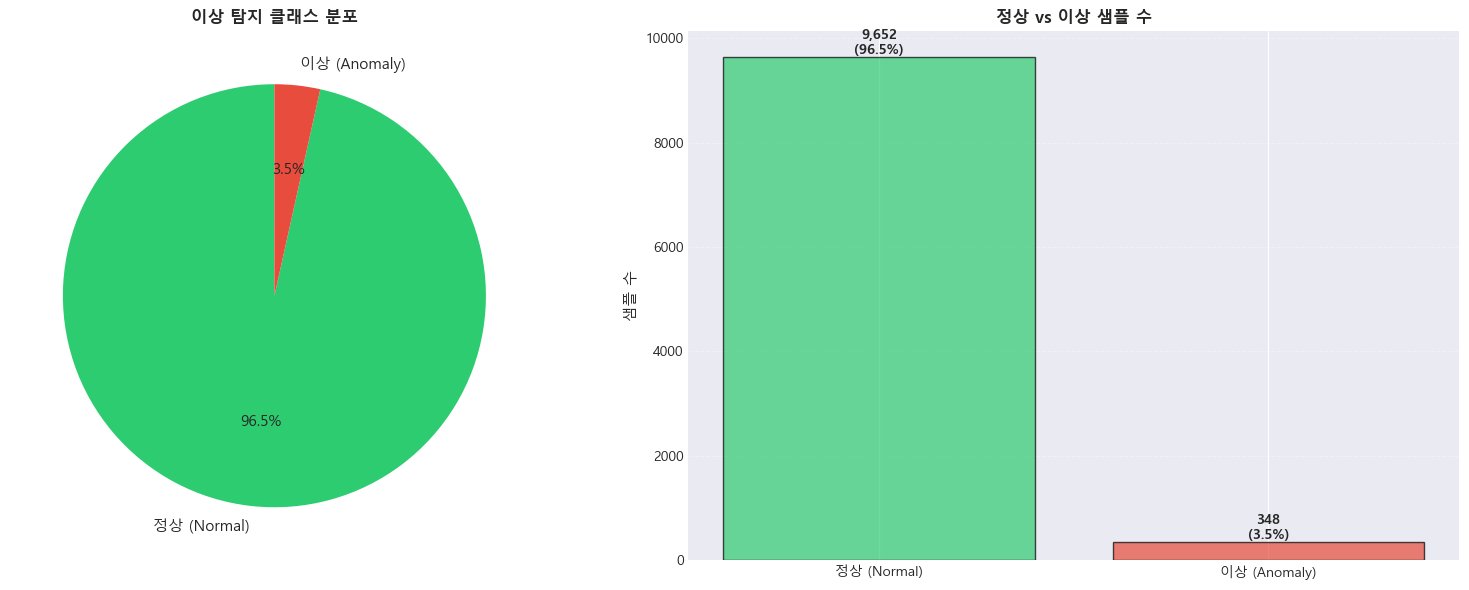

In [3]:
print("결측치:", df.isnull().sum().sum())

# 타겟 컬럼 설정 - 이상 탐지를 위한 이진 분류
class_col = 'Failure Type'

# 이상 탐지: No Failure(정상) vs 나머지(이상)으로 변환
df['Anomaly'] = (df[class_col] != 'No Failure').astype(int)
class_col = 'Anomaly'  # 0: 정상, 1: 이상

# 클래스 분포
print("\n클래스 분포 (이상 탐지):")
class_dist = df[class_col].value_counts()
print(f"정상(0): {class_dist[0]:,}개 ({class_dist[0]/len(df)*100:.2f}%)")
print(f"이상(1): {class_dist[1]:,}개 ({class_dist[1]/len(df)*100:.2f}%)")
print(f"\n불균형 비율: 1:{class_dist[0]/class_dist[1]:.2f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

status_names = ['정상 (Normal)', '이상 (Anomaly)']
colors_palette = ['#2ecc71', '#e74c3c']

# 파이 차트
axes[0].pie(class_dist.values, labels=status_names, autopct='%1.1f%%', 
            colors=colors_palette, startangle=90, textprops={'fontsize': 11})
axes[0].set_title('이상 탐지 클래스 분포', fontweight='bold', fontsize=12)

# 막대 그래프
bars = axes[1].bar(range(len(status_names)), class_dist.values, 
                    color=colors_palette, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('샘플 수', fontsize=11)
axes[1].set_title('정상 vs 이상 샘플 수', fontweight='bold', fontsize=12)
axes[1].set_xticks(range(len(status_names)))
axes[1].set_xticklabels(status_names, fontsize=10)

# 막대 위에 값 표시
for i, (bar, v) in enumerate(zip(bars, class_dist.values)):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{v:,}\n({v/len(df)*100:.1f}%)', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# 격자 추가
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

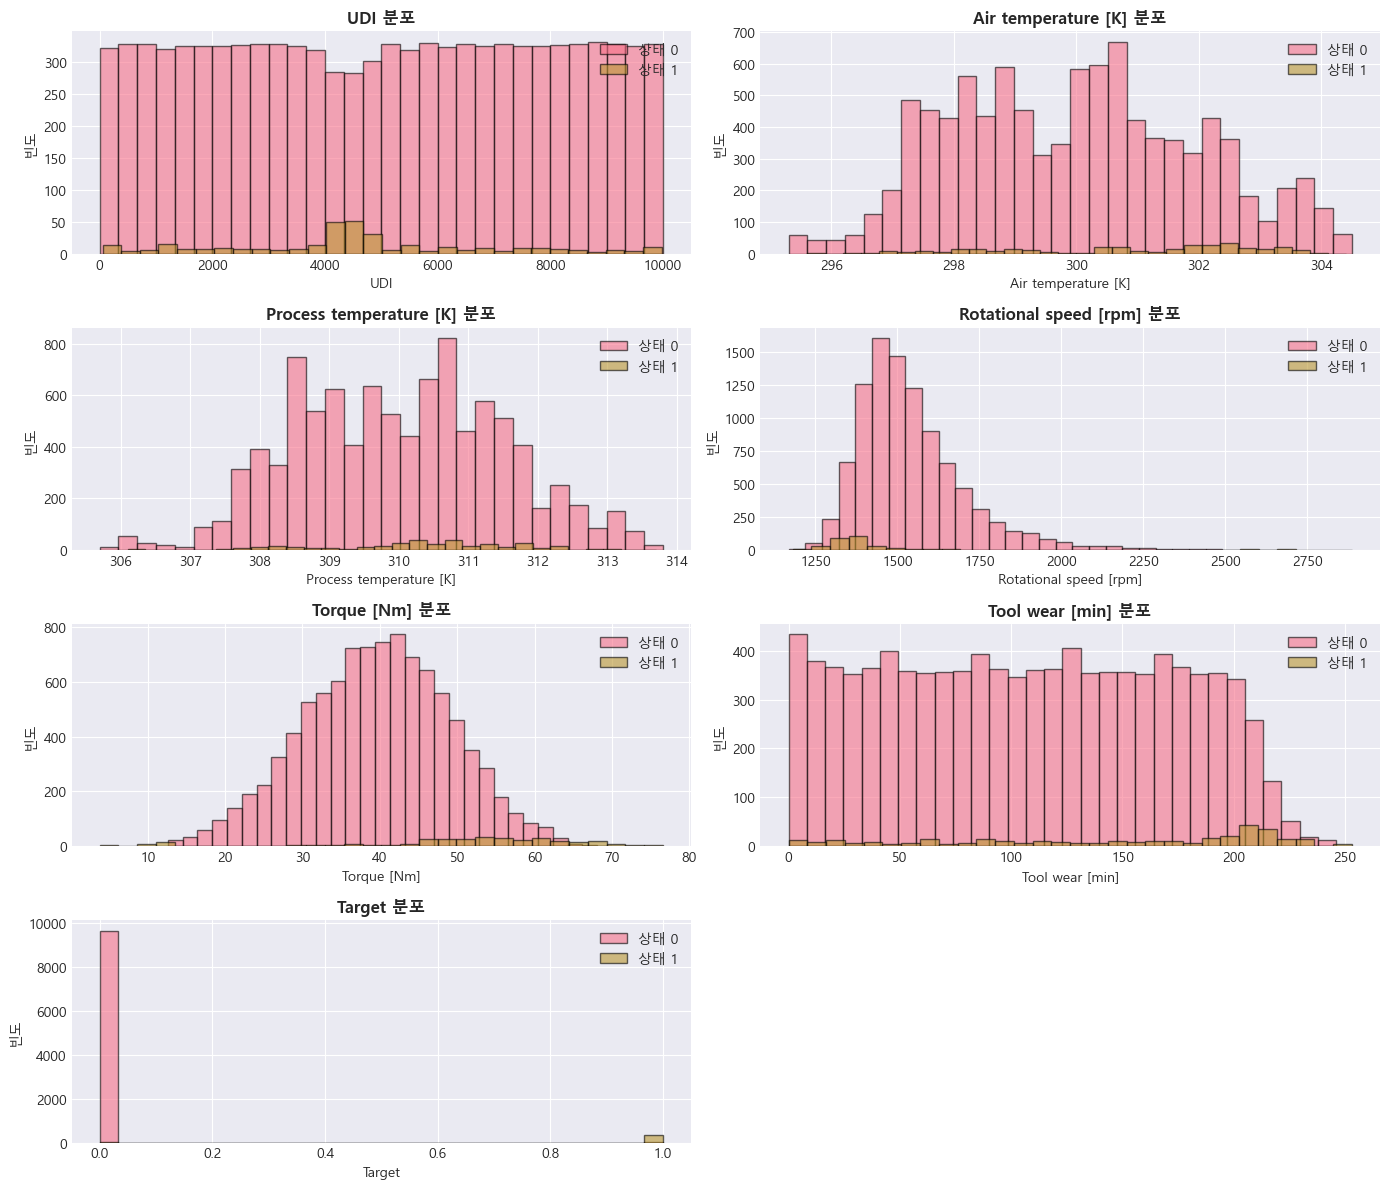


특성 간 상관계수:
                              UDI  Air temperature [K]  \
UDI                      1.000000             0.117428   
Air temperature [K]      0.117428             1.000000   
Process temperature [K]  0.324428             0.876107   
Rotational speed [rpm]  -0.006615             0.022670   
Torque [Nm]              0.003207            -0.013778   
Tool wear [min]         -0.010702             0.013853   
Target                  -0.022892             0.082556   

                         Process temperature [K]  Rotational speed [rpm]  \
UDI                                     0.324428               -0.006615   
Air temperature [K]                     0.876107                0.022670   
Process temperature [K]                 1.000000                0.019277   
Rotational speed [rpm]                  0.019277                1.000000   
Torque [Nm]                            -0.014061               -0.875027   
Tool wear [min]                         0.013488                0.0

In [4]:
feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if class_col in feature_cols:
    feature_cols.remove(class_col)

n_features = len(feature_cols)

fig, axes = plt.subplots((n_features + 1) // 2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, feature in enumerate(feature_cols):
    ax = axes[idx]
    
    for status in sorted(df[class_col].unique()):
        ax.hist(df[df[class_col] == status][feature], bins=30, alpha=0.6, 
                label=f'상태 {status}', edgecolor='black')
    
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('빈도')
    ax.set_title(f'{feature} 분포', fontweight='bold')
    ax.legend()

if n_features % 2 != 0:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

# 상관관계
print("\n특성 간 상관계수:")
corr_matrix = df[feature_cols].corr()
print(corr_matrix)

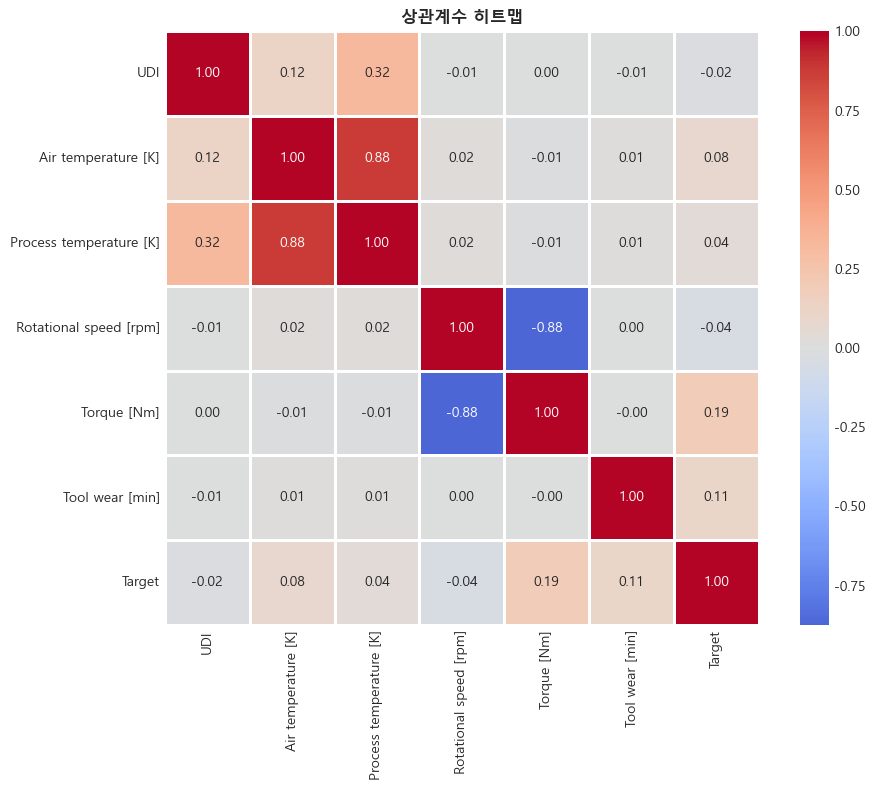

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('상관계수 히트맵', fontweight='bold')
plt.tight_layout()
plt.show()

## 3단계: 데이터 전처리

In [6]:
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
if class_col in numeric_features:
    numeric_features.remove(class_col)

X = df[numeric_features]
y = df[class_col]

# 레이블이 문자열인 경우 숫자로 인코딩
# 이상 탐지는 이미 0/1로 변환됨 (0: 정상, 1: 이상)
label_encoder = None

print(f"특성 데이터: {X.shape}")
print(f"레이블 데이터: {y.shape}")
print(f"\n이상 탐지 레이블: 0=정상, 1=이상")

# 특성 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# XGBoost 호환을 위해 컬럼명에서 특수문자 제거
clean_columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X.columns]
X_scaled = pd.DataFrame(X_scaled, columns=clean_columns)

print(f"\n표준화 전: [{X.values.min():.4f}, {X.values.max():.4f}]")
print(f"표준화 후: [{X_scaled.values.min():.4f}, {X_scaled.values.max():.4f}]")

# 데이터 분리 (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n훈련 세트: {X_train.shape}")
print(f"테스트 세트: {X_test.shape}")
print(f"\n훈련 클래스 분포: {dict(pd.Series(y_train).value_counts())}")
print(f"테스트 클래스 분포: {dict(pd.Series(y_test).value_counts())}")

특성 데이터: (10000, 7)
레이블 데이터: (10000,)

이상 탐지 레이블: 0=정상, 1=이상

표준화 전: [0.0000, 10000.0000]
표준화 후: [-3.6301, 7.5148]

훈련 세트: (8000, 7)
테스트 세트: (2000, 7)

훈련 클래스 분포: {0: np.int64(7722), 1: np.int64(278)}
테스트 클래스 분포: {0: np.int64(1930), 1: np.int64(70)}


SMOTE를 이용한 클래스 불균형 처리 (이상 탐지)
정상 샘플 수: 7,722개
이상 샘플 수: 278개
이상 비율: 3.48%
불균형 비율: 1:27.8

SMOTE 설정: k_neighbors=5 (이상 샘플이 적어 조정)

적용 전: 정상 7,722개, 이상 278개
적용 후: 정상 7,722개, 이상 7,722개


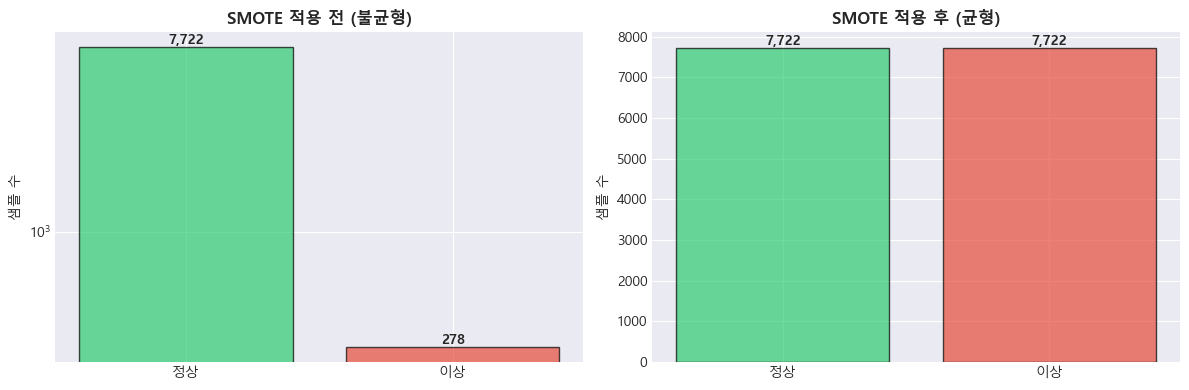

In [7]:
print("SMOTE를 이용한 클래스 불균형 처리 (이상 탐지)")

# 클래스 불균형 확인
y_train_counts = pd.Series(y_train).value_counts()
minority_class_ratio = y_train_counts.min() / len(y_train)
is_imbalanced = minority_class_ratio < 0.3

print(f"정상 샘플 수: {y_train_counts[0]:,}개")
print(f"이상 샘플 수: {y_train_counts[1]:,}개")
print(f"이상 비율: {minority_class_ratio:.2%}")
print(f"불균형 비율: 1:{y_train_counts[0]/y_train_counts[1]:.1f}")

if is_imbalanced:
    min_samples = y_train_counts[1]
    k_neighbors = min(5, min_samples - 1) if min_samples > 1 else 1
    
    print(f"\nSMOTE 설정: k_neighbors={k_neighbors} (이상 샘플이 적어 조정)")
    
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    
    print(f"\n적용 전: 정상 {y_train_counts[0]:,}개, 이상 {y_train_counts[1]:,}개")
    balanced_counts = pd.Series(y_train_balanced).value_counts()
    print(f"적용 후: 정상 {balanced_counts[0]:,}개, 이상 {balanced_counts[1]:,}개")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # SMOTE 적용 전
    axes[0].bar(['정상', '이상'], y_train_counts.values, 
                color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
    axes[0].set_title('SMOTE 적용 전 (불균형)', fontweight='bold')
    axes[0].set_ylabel('샘플 수')
    axes[0].set_yscale('log')
    for i, v in enumerate(y_train_counts.values):
        axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
    
    # SMOTE 적용 후
    axes[1].bar(['정상', '이상'], balanced_counts.values,
                color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
    axes[1].set_title('SMOTE 적용 후 (균형)', fontweight='bold')
    axes[1].set_ylabel('샘플 수')
    for i, v in enumerate(balanced_counts.values):
        axes[1].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("클래스가 균형적입니다.")
    X_train_balanced = X_train
    y_train_balanced = y_train

## 4단계: 비지도학습 모델

In [8]:
unsupervised_predictions = {}
unsupervised_scores = {}

# K-Means (이상 탐지: 2개 클러스터)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train)
y_pred_kmeans = kmeans.predict(X_test)
unsupervised_predictions['K-Means'] = y_pred_kmeans
silhouette_kmeans = silhouette_score(X_test, y_pred_kmeans)
unsupervised_scores['K-Means'] = silhouette_kmeans
print(f"K-Means Silhouette: {silhouette_kmeans:.4f}")

# Gaussian Mixture Model (이상 탐지: 2개 컴포넌트)
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X_train)
y_pred_gmm = gmm.predict(X_test)
unsupervised_predictions['GMM'] = y_pred_gmm
silhouette_gmm = silhouette_score(X_test, y_pred_gmm)
unsupervised_scores['GMM'] = silhouette_gmm
print(f"Gaussian Mixture Model Silhouette: {silhouette_gmm:.4f}")

# Isolation Forest (이상 탐지 특화)
contamination_rate = y_train.sum() / len(y_train)  # 실제 이상 비율
iso_forest = IsolationForest(contamination=contamination_rate, random_state=42, n_estimators=100)
iso_forest.fit(X_train)
y_pred_iso = iso_forest.predict(X_test)
y_pred_iso = (y_pred_iso == -1).astype(int)  # -1(이상) -> 1, 1(정상) -> 0
unsupervised_predictions['Isolation Forest'] = y_pred_iso
print(f"Isolation Forest 탐지된 이상치: {y_pred_iso.sum()} (실제: {y_test.sum()})")

K-Means Silhouette: 0.2226
Gaussian Mixture Model Silhouette: 0.5236
Isolation Forest 탐지된 이상치: 66 (실제: 70)


## 5단계: 지도학습 모델

In [9]:
supervised_predictions = {}
supervised_proba = {}

# SVM
svm = SVC(kernel='rbf', C=10, random_state=42, probability=True)
svm.fit(X_train_balanced, y_train_balanced)
y_pred_svm = svm.predict(X_test)
y_proba_svm = svm.predict_proba(X_test)[:, 1] if len(svm.classes_) > 1 else svm.decision_function(X_test)
supervised_predictions['SVM'] = y_pred_svm
supervised_proba['SVM'] = y_proba_svm

# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_balanced, y_train_balanced)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
supervised_predictions['Random Forest'] = y_pred_rf
supervised_proba['Random Forest'] = y_proba_rf

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train_balanced, y_train_balanced)
y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]
supervised_predictions['Gradient Boosting'] = y_pred_gb
supervised_proba['Gradient Boosting'] = y_proba_gb

# XGBoost
xgb = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbosity=0)
xgb.fit(X_train_balanced, y_train_balanced)
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
supervised_predictions['XGBoost'] = y_pred_xgb
supervised_proba['XGBoost'] = y_proba_xgb

print(f"SVM 정확도: {svm.score(X_test, y_test):.4f}")
print(f"Random Forest 정확도: {rf.score(X_test, y_test):.4f}")
print(f"Gradient Boosting 정확도: {gb.score(X_test, y_test):.4f}")
print(f"XGBoost 정확도: {xgb.score(X_test, y_test):.4f}")



SVM 정확도: 0.9990
Random Forest 정확도: 0.9985
Gradient Boosting 정확도: 0.9975
XGBoost 정확도: 0.9965


## 6단계: 모델 평가

In [10]:
def evaluate_model(y_true, y_pred, y_proba=None, model_name=""):
    """이상 탐지 모델 성능 평가"""
    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0, pos_label=1),
        'Recall': recall_score(y_true, y_pred, zero_division=0, pos_label=1),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0, pos_label=1),
    }
    
    if y_proba is not None:
        try:
            results['ROC-AUC'] = roc_auc_score(y_true, y_proba)
        except:
            results['ROC-AUC'] = 'N/A'
    else:
        results['ROC-AUC'] = 'N/A'
    
    return results

print("이상 탐지 모델 성능 평가\n")

evaluation_results = []

# 비지도학습
print("="*80)
print("비지도학습 (이상 탐지)")
print("="*80)
for model_name in unsupervised_predictions.keys():
    y_pred = unsupervised_predictions[model_name]
    results = evaluate_model(y_test, y_pred, model_name=f'{model_name}')
    evaluation_results.append(results)
    print(f"\n[{model_name}]")
    print(f"  정확도: {results['Accuracy']:.4f}")
    print(f"  정밀도: {results['Precision']:.4f} (이상 샘플 중 맞춘 비율)")
    print(f"  재현율: {results['Recall']:.4f} (실제 이상을 찾은 비율)")
    print(f"  F1: {results['F1-Score']:.4f}")

# 지도학습
print("\n" + "="*80)
print("지도학습 (이상 탐지)")
print("="*80)
for model_name in supervised_predictions.keys():
    y_pred = supervised_predictions[model_name]
    y_proba = supervised_proba[model_name]
    results = evaluate_model(y_test, y_pred, y_proba, model_name=model_name)
    evaluation_results.append(results)
    print(f"\n[{model_name}]")
    print(f"  정확도: {results['Accuracy']:.4f}")
    print(f"  정밀도: {results['Precision']:.4f} (이상 샘플 중 맞춘 비율)")
    print(f"  재현율: {results['Recall']:.4f} (실제 이상을 찾은 비율)")
    print(f"  F1: {results['F1-Score']:.4f}")
    if results['ROC-AUC'] != 'N/A':
        print(f"  ROC-AUC: {results['ROC-AUC']:.4f}")

results_df = pd.DataFrame(evaluation_results)
print("\n" + "="*80)
print("전체 이상 탐지 성능 비교 (요약)")
print("="*80)
print(results_df.to_string(index=False))

이상 탐지 모델 성능 평가

비지도학습 (이상 탐지)

[K-Means]
  정확도: 0.5325
  정밀도: 0.0189 (이상 샘플 중 맞춘 비율)
  재현율: 0.2429 (실제 이상을 찾은 비율)
  F1: 0.0351

[GMM]
  정확도: 0.0060
  정밀도: 0.0010 (이상 샘플 중 맞춘 비율)
  재현율: 0.0286 (실제 이상을 찾은 비율)
  F1: 0.0020

[Isolation Forest]
  정확도: 0.9930
  정밀도: 0.9242 (이상 샘플 중 맞춘 비율)
  재현율: 0.8714 (실제 이상을 찾은 비율)
  F1: 0.8971

지도학습 (이상 탐지)

[SVM]
  정확도: 0.9990
  정밀도: 1.0000 (이상 샘플 중 맞춘 비율)
  재현율: 0.9714 (실제 이상을 찾은 비율)
  F1: 0.9855
  ROC-AUC: 0.9880

[Random Forest]
  정확도: 0.9985
  정밀도: 0.9855 (이상 샘플 중 맞춘 비율)
  재현율: 0.9714 (실제 이상을 찾은 비율)
  F1: 0.9784
  ROC-AUC: 0.9907

[Gradient Boosting]
  정확도: 0.9975
  정밀도: 0.9577 (이상 샘플 중 맞춘 비율)
  재현율: 0.9714 (실제 이상을 찾은 비율)
  F1: 0.9645
  ROC-AUC: 0.9913

[XGBoost]
  정확도: 0.9965
  정밀도: 0.9315 (이상 샘플 중 맞춘 비율)
  재현율: 0.9714 (실제 이상을 찾은 비율)
  F1: 0.9510
  ROC-AUC: 0.9924

전체 이상 탐지 성능 비교 (요약)
            Model  Accuracy  Precision   Recall  F1-Score   ROC-AUC
          K-Means    0.5325   0.018910 0.242857  0.035088       N/A
              GMM    0.0060   0

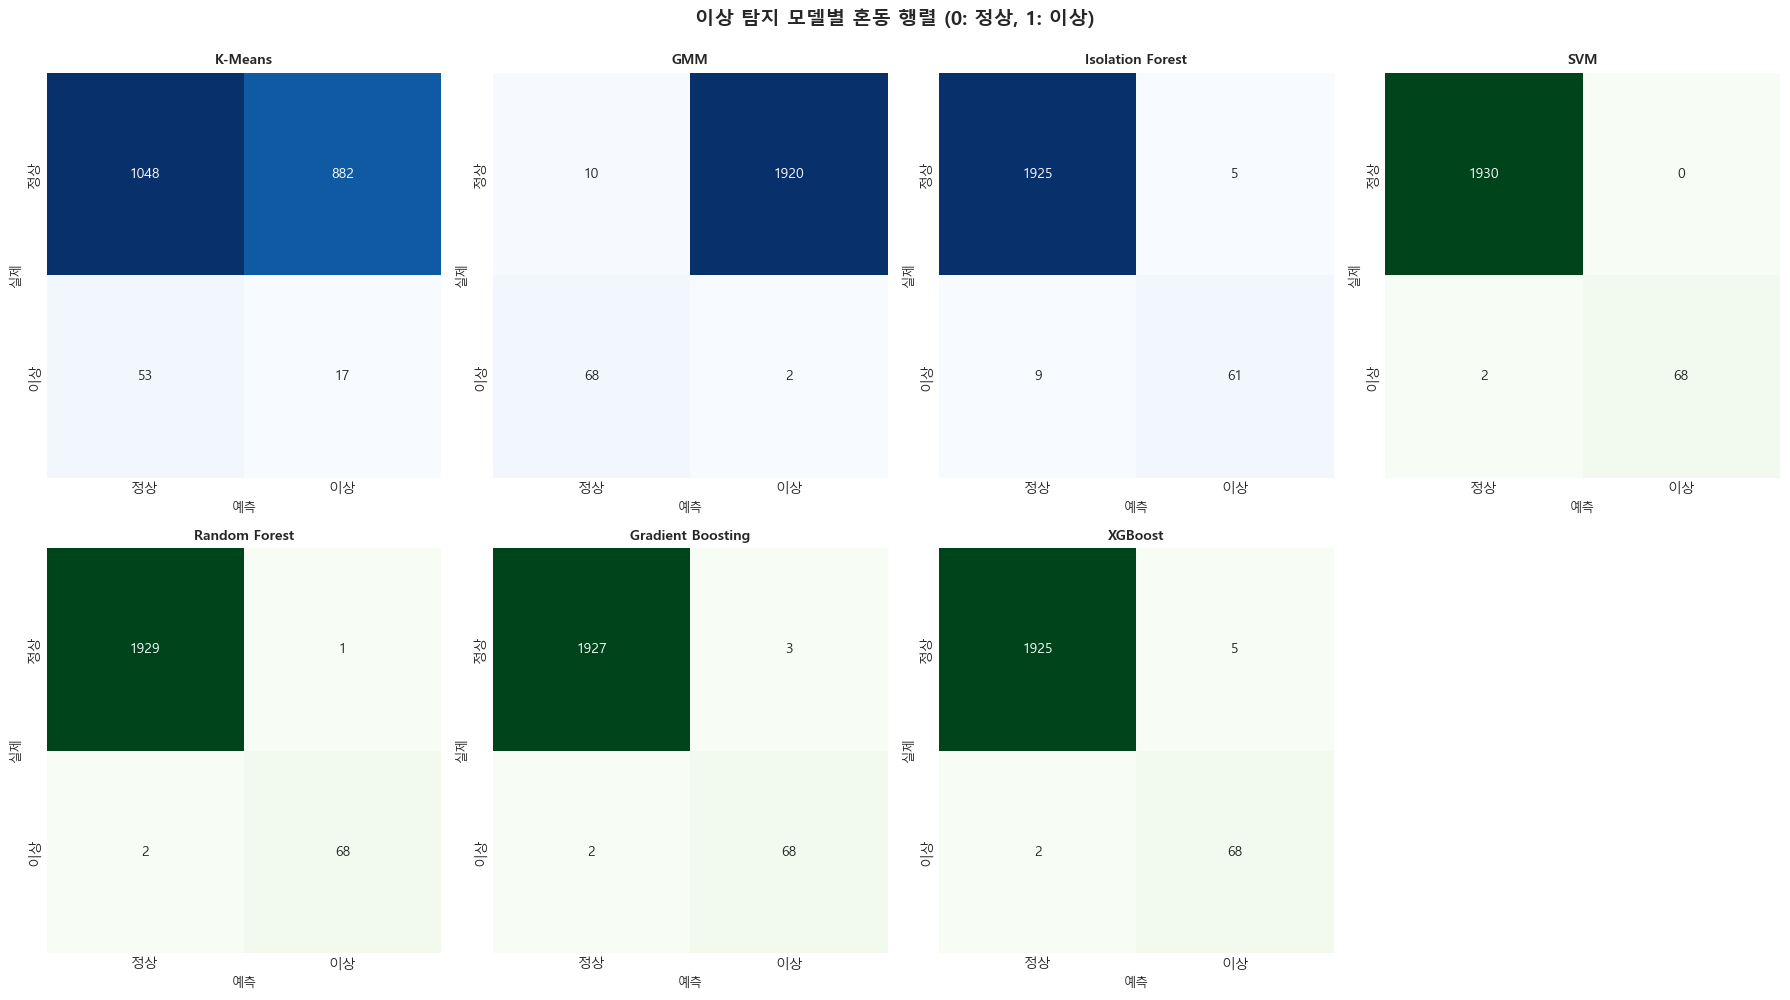

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('이상 탐지 모델별 혼동 행렬 (0: 정상, 1: 이상)', fontsize=14, fontweight='bold', y=0.995)

models_list = list(unsupervised_predictions.keys()) + list(supervised_predictions.keys())

for idx, model_name in enumerate(models_list):
    ax = axes[idx // 4, idx % 4]
    
    if model_name in unsupervised_predictions:
        y_pred = unsupervised_predictions[model_name]
        cmap = 'Blues'
    else:
        y_pred = supervised_predictions[model_name]
        cmap = 'Greens'
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, cbar=False,
                xticklabels=['정상', '이상'], yticklabels=['정상', '이상'])
    ax.set_title(model_name, fontweight='bold', fontsize=10)
    ax.set_ylabel('실제', fontsize=9)
    ax.set_xlabel('예측', fontsize=9)

# 빈 subplot 제거
for idx in range(len(models_list), 8):
    fig.delaxes(axes[idx // 4, idx % 4])

plt.tight_layout()
plt.show()

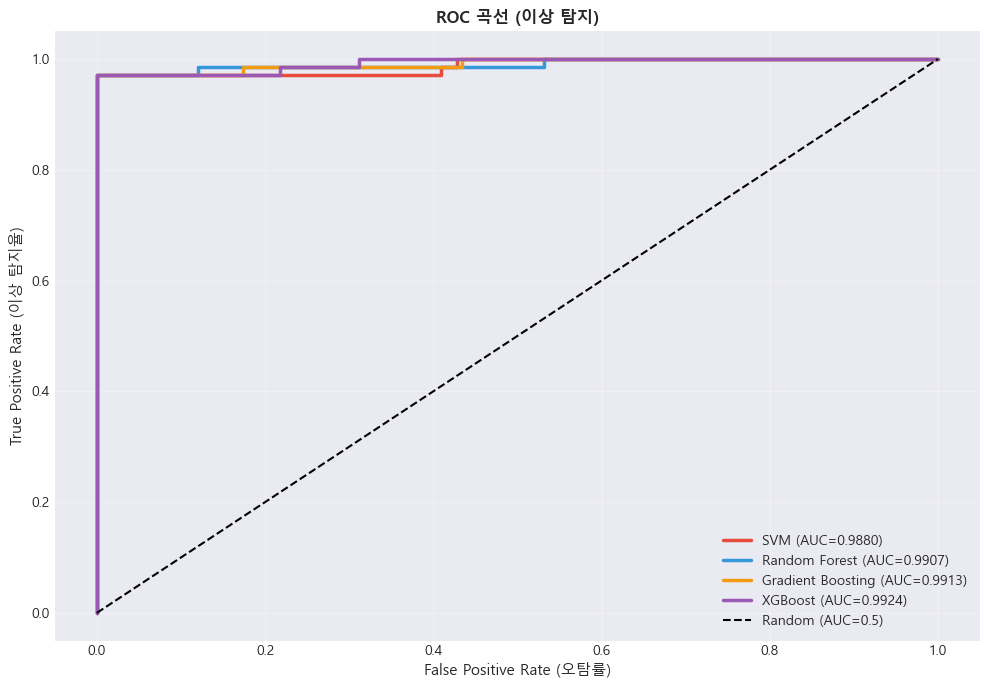

In [12]:
if len(np.unique(y_test)) == 2:
    fig, ax = plt.subplots(figsize=(10, 7))
    
    colors = ['#e74c3c', '#3498db', '#f39c12', '#9b59b6']
    
    for idx, (model_name, y_proba) in enumerate(supervised_proba.items()):
        try:
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            auc = roc_auc_score(y_test, y_proba)
            ax.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.4f})', 
                    linewidth=2.5, color=colors[idx % len(colors)])
        except:
            pass
    
    ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)', linewidth=1.5)
    
    ax.set_xlabel('False Positive Rate (오탐률)', fontsize=11)
    ax.set_ylabel('True Positive Rate (이상 탐지율)', fontsize=11)
    ax.set_title('ROC 곡선 (이상 탐지)', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("이진 분류가 아니므로 ROC 곡선을 그릴 수 없습니다.")

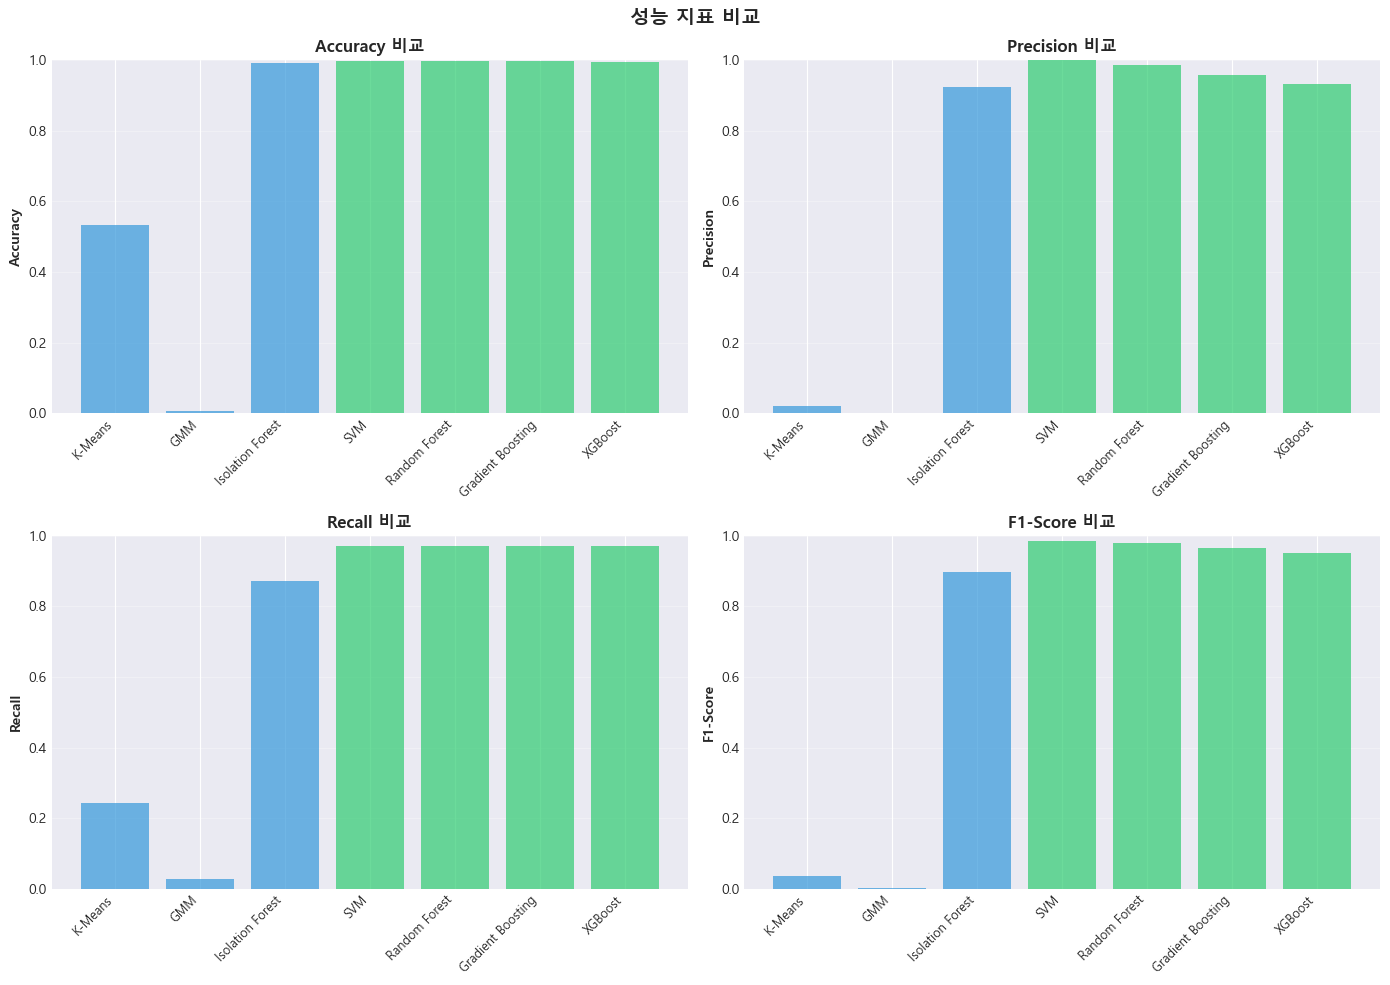

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('성능 지표 비교', fontsize=14, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    models = results_df['Model'].values
    values = results_df[metric].values
    
    # 지도학습/비지도학습 색상 구분
    colors_list = ['#3498db' if 'Isolation' in m or 'K-Means' in m or 'GMM' in m else '#2ecc71' for m in models]
    
    ax.bar(range(len(models)), values, color=colors_list, alpha=0.7)
    ax.set_ylabel(metric, fontweight='bold')
    ax.set_title(f'{metric} 비교', fontweight='bold')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7단계: 특성 중요도

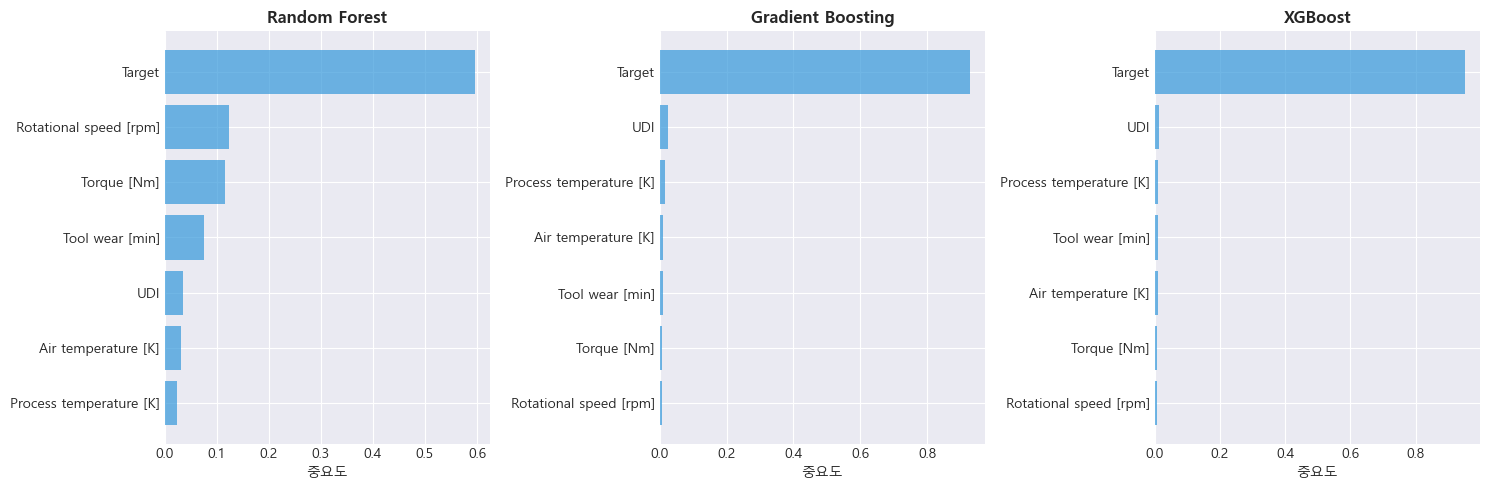

In [14]:
feature_importance_models = {}

if hasattr(rf, 'feature_importances_'):
    feature_importance_models['Random Forest'] = rf.feature_importances_

if hasattr(gb, 'feature_importances_'):
    feature_importance_models['Gradient Boosting'] = gb.feature_importances_

if hasattr(xgb, 'feature_importances_'):
    feature_importance_models['XGBoost'] = xgb.feature_importances_

if feature_importance_models:
    fig, axes = plt.subplots(1, len(feature_importance_models), figsize=(15, 5))
    if len(feature_importance_models) == 1:
        axes = [axes]
    
    for idx, (model_name, importance) in enumerate(feature_importance_models.items()):
        sorted_idx = np.argsort(importance)[::-1][:10]
        
        ax = axes[idx]
        ax.barh(range(len(sorted_idx)), importance[sorted_idx], color='#3498db', alpha=0.7)
        ax.set_yticks(range(len(sorted_idx)))
        ax.set_yticklabels(X.columns[sorted_idx], fontsize=10)
        ax.set_xlabel('중요도')
        ax.set_title(f'{model_name}', fontweight='bold')
        ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

## 결론

In [15]:
print("="*70)
print("이상 탐지 분석 요약")
print("="*70)

print(f"\n1. 데이터")
print(f"   샘플: {len(df):,} | 특성: {len(numeric_features)}")
print(f"   정상: {(y==0).sum():,}개 ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"   이상: {(y==1).sum():,}개 ({(y==1).sum()/len(y)*100:.1f}%)")
print(f"   불균형 비율: 1:{(y==0).sum()/(y==1).sum():.2f}")

print(f"\n2. 모델 수")
print(f"   비지도학습: {len(unsupervised_predictions)}")
print(f"   지도학습: {len(supervised_predictions)}")

best_model = results_df.loc[results_df['F1-Score'].idxmax()]
print(f"\n3. 최고 성능 (F1-Score 기준)")
print(f"   모델: {best_model['Model']}")
print(f"   정확도: {best_model['Accuracy']:.4f}")
print(f"   정밀도: {best_model['Precision']:.4f}")
print(f"   재현율: {best_model['Recall']:.4f}")
print(f"   F1-Score: {best_model['F1-Score']:.4f}")

print(f"\n4. 지도학습 vs 비지도학습")
sup_f1 = results_df[~results_df['Model'].str.contains('Isolation|K-Means|GMM')]['F1-Score'].mean()
unsup_f1 = results_df[results_df['Model'].str.contains('Isolation|K-Means|GMM')]['F1-Score'].mean()
print(f"   지도학습 평균 F1: {sup_f1:.4f}")
print(f"   비지도학습 평균 F1: {unsup_f1:.4f}")
print(f"   차이: {abs(sup_f1 - unsup_f1):.4f}")

print(f"\n5. 이상 탐지 주요 결론")
print(f"   - 불균형 데이터에서 F1-Score가 중요한 평가 지표")
print(f"   - 재현율(Recall): 실제 이상을 얼마나 찾았는가")
print(f"   - 정밀도(Precision): 이상으로 예측한 것이 얼마나 정확한가")
print(f"   - 비지도학습은 레이블 없이도 이상 패턴 탐지 가능")
print(f"   - 지도학습은 레이블 활용으로 더 정확한 이상 분류")
print(f"   - Isolation Forest는 이상 탐지 특화 알고리즘")

print("\n이상 탐지 분석 완료")
print("="*70)

이상 탐지 분석 요약

1. 데이터
   샘플: 10,000 | 특성: 7
   정상: 9,652개 (96.5%)
   이상: 348개 (3.5%)
   불균형 비율: 1:27.74

2. 모델 수
   비지도학습: 3
   지도학습: 4

3. 최고 성능 (F1-Score 기준)
   모델: SVM
   정확도: 0.9990
   정밀도: 1.0000
   재현율: 0.9714
   F1-Score: 0.9855

4. 지도학습 vs 비지도학습
   지도학습 평균 F1: 0.9699
   비지도학습 평균 F1: 0.3114
   차이: 0.6585

5. 이상 탐지 주요 결론
   - 불균형 데이터에서 F1-Score가 중요한 평가 지표
   - 재현율(Recall): 실제 이상을 얼마나 찾았는가
   - 정밀도(Precision): 이상으로 예측한 것이 얼마나 정확한가
   - 비지도학습은 레이블 없이도 이상 패턴 탐지 가능
   - 지도학습은 레이블 활용으로 더 정확한 이상 분류
   - Isolation Forest는 이상 탐지 특화 알고리즘

이상 탐지 분석 완료


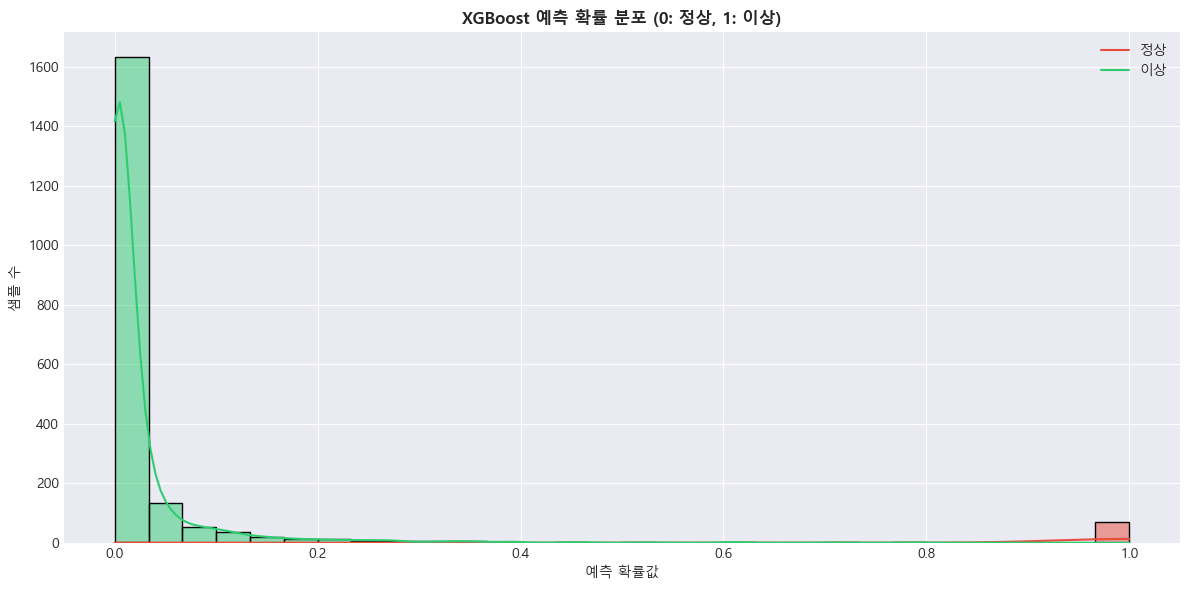

In [16]:
## 예측 확률값 분포 시각화 (XGBoost)
plt.figure(figsize=(12, 6))
sns.histplot(x=supervised_proba['XGBoost'], hue=y_test, bins=30, kde=True, palette=['#2ecc71', '#e74c3c'])
plt.title('XGBoost 예측 확률 분포 (0: 정상, 1: 이상)', fontweight='bold')
plt.xlabel('예측 확률값')
plt.ylabel('샘플 수')
plt.legend(['정상', '이상'])
plt.tight_layout()
plt.show()